# Uncertainty and sentiment in annual and quarterly reports

FRE-GY 7871 A · Assignment 1 · Filing dates: 2021–2025

This notebook computes dictionary-based negative sentiment and uncertainty,
constructs filing-event outcomes and controls, and presents six tables and one
figure. Negative sentiment and uncertainty are analysed separately. The company
universe is derived from the supplied ARK holdings and resolved to SEC filers;
actual acquisition and sample counts appear below.

Run all cells after downloading the complete local filing corpus, lexicons,
prices, corporate actions and filing-specific share counts. The computation
requires local data excluded from the repository. Tables and the figure are
recomputed when the notebook runs. Saved outputs are aggregate results; the
notebook does not embed filing documents or the observation-level dataset.


In [1]:
from pathlib import Path
import sys
import json
import io
from contextlib import redirect_stdout
from collections import Counter

import numpy as np
import pandas as pd
from IPython.display import display, Markdown, Image

# Execution from the repository or its immediate project directory is supported.
ROOT = Path.cwd().resolve()
if not (ROOT / 'src' / 'analysis.py').is_file():
    if (ROOT / 'assignment' / 'src' / 'analysis.py').is_file():
        ROOT = ROOT / 'assignment'
    else:
        raise RuntimeError('Open this notebook with the assignment repository as the working directory.')
sys.path.insert(0, str(ROOT))
from src.analysis import run_analysis
from src.scoring import score_corpus
from src.config import OUTPUT_DIR
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)


## Tone measures

For dictionary category $c$, the proportional score is
$P_{cj}=\sum_{i\in c}tf_{ij}/W_j$, where $W_j$ is the number of tokens in
filing $j$. Percentages in descriptive tables equal $100P_{cj}$; regressions
use the fraction in its original units.

The equation (1) weighted score is

$$T_{cj}=\sum_{i\in c:tf_{ij}>0}
\frac{1+\ln(tf_{ij})}{1+\ln(a_j)}\ln\left(\frac{N}{df_i}\right),
\qquad a_j=\frac{W_j}{V_j}.$$

Here $V_j$ is the number of distinct words in filing $j$, $N$ is the number
of documents in the estimation corpus and $df_i$ is document frequency.
All logarithms are natural. The weighted score is a sum, not a proportion.
Document frequencies are fitted on the final sample and refitted separately
for the annual-report and quarterly-report regression samples.

The three-document example below reproduces the assignment's reference values.


In [2]:
example_documents = [Counter('LOSS LOSS RISK GAIN'.split()),
                     Counter('LOSS GAIN GAIN'.split()),
                     Counter('RISK RISK RISK GAIN'.split())]
equation_example = score_corpus(example_documents, {'Example': {'LOSS', 'RISK'}})
equation_example.index = ['d1', 'd2', 'd3']
equation_example['a_j'] = equation_example.n_words / equation_example.n_distinct
np.testing.assert_allclose(equation_example.Example_tfidf, [0.8480, 0.2885, 0.5026], atol=0.00005)
display(equation_example[['a_j', 'Example_prop', 'Example_tfidf']].style.format('{:.4f}'))


,a_j,Example_prop,Example_tfidf
d1,1.3333,0.7500,0.8480
d2,1.5000,0.3333,0.2885
d3,2.0000,0.7500,0.5026


## Sample and event construction

Filters remove amendments and failed parses; require at least 2,000 words for
10-Ks or 1,000 for 10-Qs; and retain the earliest filing per company and
calendar quarter. Market filters require a usable event date, a preceding close
of at least $3, sufficient return history and complete event windows. Missing
filing-specific shares and other controls are explicitly counted in Table 1.

Acceptance timestamps are converted from UTC to Eastern time. Acceptance at or
after 16:00 shifts its calendar date forward one day. Day 0 is the first NYSE
trading day on or after the later of this date and the filing date.

Total-return adjusted closes measure buy-and-hold excess returns against SPY
for days [0,+3], starting from the close on day −1. Realised volatility uses
returns over [−60,−6] before filing and [+4,+63] after filing, annualised by
$\sqrt{252}$. The market histories extend through April 2026 to cover the
post-filing windows for December 2025 filings.

Historical nominal closes determine the $3 filter and size. Share counts must
match the scored accession and use a valid cover-page instant no later than
filing; weighted-average shares are not a substitute. Historical nominal
volume times nominal close gives dollar volume. Corporate actions are retained
to undo subsequent splits in Yahoo's split-adjusted price and volume histories.


In [3]:
# This call checks acquisition completeness before constructing the sample.
# Its detailed progress text is suppressed; aggregate counts are displayed below.
with redirect_stdout(io.StringIO()):
    analysis_sample = run_analysis()
audit = json.loads((OUTPUT_DIR / 'audit.json').read_text())
print(f"Final sample: {audit['final_filings']:,} filings from {audit['final_companies']:,} companies.")
print(f"Day-0 shifts before market filters: {audit['day0_moved_before_market_filters']:,}.")
print(f"Day-0 shifts in the final sample: {audit['day0_moved_final']:,}.")
print('Dictionary word counts:', audit['lexicon_counts'])
print('Words shared by the two dictionaries:', audit['lexicon_overlap'])

def show_table(number):
    table = pd.read_csv(OUTPUT_DIR / f'table{number}.csv')
    display(table.style.format(precision=5, na_rep='—'))
    return table


Final sample: 1,437 filings from 84 companies.
Day-0 shifts before market filters: 938.
Day-0 shifts in the final sample: 789.
Dictionary word counts: {'Negative': 2355, 'Uncertainty': 297}
Words shared by the two dictionaries: 40


## Table 1. Sample filters

Removal counts follow the stated order; additional complete-case restrictions are shown explicitly.

In [4]:
display(pd.read_csv(OUTPUT_DIR / 'table1_universe.csv'))
table1 = show_table(1)

,filter,removed,remaining,unit
0,Raw holding identifiers,0,130,identifiers
1,Funds and non-company securities,4,126,identifiers
2,Foreign local listings,8,118,identifiers
3,Unresolved SEC identifiers,3,115,identifiers
4,Combine share classes by company CIK,1,114,companies
5,first_10x_after_sample,6,108,companies
6,foreign_reporting_forms,17,91,companies


,filter,removed,remaining,companies
0,All 10-K/Q and amendments,0,1709,91
1,Remove amendments and parse failures,46,1663,91
2,"Minimum words: 2,000 K / 1,000 Q",0,1663,91
3,Earliest company filing each quarter,8,1655,91
4,Usable day 0 and prior price at least $3,108,1547,91
5,60 observed returns before and after,23,1524,90
6,Complete event and volatility windows,0,1524,90
7,Accession-matched outstanding shares,70,1454,85
8,Complete liquidity and model controls,17,1437,84


## Table 2. Tone by report type

Proportional scores are percentages. Weighted scores are in equation (1) units. Annual and quarterly reports are reported separately.

In [5]:
table2 = show_table(2)

,form,measure,n,mean,sd,p25,median,p75,min,max
0,10-K,Negative words (%),349,2.32075,0.40082,2.06740,2.34847,2.58002,1.02527,3.33040
1,10-K,Uncertainty words (%),349,1.93943,0.24299,1.79369,1.96775,2.11827,1.21396,2.48825
2,10-K,Negative tf.idf,349,100.63444,38.30635,71.36892,92.34644,127.87392,30.99056,212.81085
3,10-K,Uncertainty tf.idf,349,15.78849,5.82077,11.70514,14.64733,18.97148,3.68324,38.58092
4,10-Q,Negative words (%),1088,2.11825,0.94212,1.25981,1.96989,2.99374,0.29598,4.71033
5,10-Q,Uncertainty words (%),1088,1.81747,0.58103,1.32616,1.66448,2.40821,0.74746,3.25979
6,10-Q,Negative tf.idf,1088,92.77253,76.74455,28.44300,64.51057,148.03568,2.71057,304.80639
7,10-Q,Uncertainty tf.idf,1088,15.82683,8.46234,9.27394,14.09169,21.34266,2.66027,45.61970


## Table 3. Frequent dictionary words

Counts pool the final corpus. Each share is the word's count divided by all observed tokens in its dictionary category.

In [6]:
table3 = show_table(3)
print('Top-ten shares of category tokens (%):', audit['top10_shares'])

,category,rank,word,count,share_pct
0,Negative,1,LOSS,67413,5.13761
1,Negative,2,ADVERSELY,51626,3.93447
2,Negative,3,LOSSES,42225,3.21801
3,Negative,4,CLAIMS,38374,2.92452
4,Negative,5,ADVERSE,36179,2.75724
5,Negative,6,AGAINST,31841,2.42663
6,Negative,7,LITIGATION,25624,1.95283
7,Negative,8,UNABLE,25352,1.93210
8,Negative,9,HARM,24954,1.90177
9,Negative,10,FAILURE,23263,1.77290


Top-ten shares of category tokens (%): {'Negative': 27.958071770922007, 'Uncertainty': 74.27848630295946}


## Negative sentiment and uncertainty correlations

Pearson correlations are reported for proportional and weighted scores in the full sample and by report type. Weighted scores are refitted within each reported sample.

In [7]:
display(pd.DataFrame(audit['correlations']).style.format(precision=4, na_rep='—'))

,form,prop,tfidf
0,All,0.8341,0.9190
1,10-K,0.7245,0.8381
2,10-Q,0.8385,0.9221


## Filing example

The example selects the largest difference between the negative-tone and uncertainty percentile ranks. This is a descriptive contrast, not a randomly selected or representative report.

In [8]:
example = audit['example']
display(Markdown(f"**{example['ticker']} · {example['form']} · {example['filing_date']}**"))
print(f"Negative words: {example['negative_pct']:.3f}%; uncertainty words: {example['uncertainty_pct']:.3f}%.")
print(f"Percentile ranks: negative {100*example['negative_percentile']:.1f}, uncertainty {100*example['uncertainty_percentile']:.1f}.")
display(Markdown('> ' + example['sentence'].replace('\n', ' ')))
display(Markdown(f"[SEC filing]({example['doc_url']}) · Accession {example['accession']}"))


**TSLA · 10-Q · 2023-10-23**

Negative words: 2.774%; uncertainty words: 1.047%.
Percentile ranks: negative 71.9, uncertainty 4.5.


> On October 27, 2021, the Court approved the parties’ joint stipulation that, among other things, (a) all claims against Kimbal Musk and Steve Jurvetson …

[SEC filing](https://www.sec.gov/Archives/edgar/data/1318605/000162828023034847/tsla-20230930.htm) · Accession 0001628280-23-034847

## Trend specifications

For each tone measure, quarter-level means estimate

$$\bar T_q=\alpha+\beta\tau_q+\sum_{s=2}^4\delta_sD_{sq}+\varepsilon_q.$$

Time $\tau_q$ is elapsed years from 2021Q1; $\beta$ is annual change.
Ordinary OLS inference and heteroskedasticity/autocorrelation-consistent
inference with four quarterly lags are both reported.

The filing-level model is

$$T_{iq}=\alpha_i+\beta\tau_q+\sum_{s=2}^4\delta_sD_{sq}
+\theta K_{iq}+\varepsilon_{iq},$$

where $\alpha_i$ is a firm effect and $K$ is a 10-K indicator. This model
controls firm composition and report type. A saturated calendar-quarter effect
would absorb the linear trend and is therefore excluded. The 10-K indicator
is omitted in samples containing only one report type.

Firm-clustered and two-way firm/calendar-quarter clustered inference are
reported. Two-way p-values and intervals use $\min(G_{firm},G_{quarter})-1$
degrees of freedom. Non-estimable or nonpositive-variance cases are labelled
rather than assigned a p-value.


## Table 4. Tone trends

The same specifications are estimated for the full sample, 10-Ks and 10-Qs. Separate report-type samples refit weighted scores on their own documents.

In [9]:
table4 = show_table(4)

,model,outcome,term,inference,n,firm_clusters,quarter_clusters,coef,se,t,p,ci_low,ci_high,mde80,df_inference,r_squared,controls,fixed_effects,form_control,dropped_nuisance,design_rank,status,measure,sample
0,aggregate_trend,Negative_prop,time_years,OLS,20,0,20,0.00011,0.00011,1.02996,0.31935,-0.00012,0.00034,0.00032,15,0.70010,"time_years,season2,season3,season4",—,False,—,5,ok,Negative_prop,All
1,aggregate_trend,Negative_prop,time_years,HAC4,20,0,20,0.00011,0.00013,0.82606,0.42171,-0.00018,0.00040,0.00040,15,0.70010,"time_years,season2,season3,season4",—,False,—,5,ok,Negative_prop,All
2,within_firm_trend,Negative_prop,time_years,firm_cluster,1437,84,20,0.00004,0.00013,0.30826,0.75866,-0.00021,0.00029,0.00036,83,0.74369,"time_years,season2,season3,season4",cik,True,—,89,ok,Negative_prop,All
3,within_firm_trend,Negative_prop,time_years,firm_quarter_cluster,1437,84,20,0.00004,0.00012,0.33585,0.74066,-0.00021,0.00029,0.00034,19,0.74369,"time_years,season2,season3,season4",cik,True,—,89,ok,Negative_prop,All
4,aggregate_trend,Uncertainty_prop,time_years,OLS,20,0,20,-0.00008,0.00007,-1.27530,0.22160,-0.00023,0.00006,0.00020,15,0.71820,"time_years,season2,season3,season4",—,False,—,5,ok,Uncertainty_prop,All
5,aggregate_trend,Uncertainty_prop,time_years,HAC4,20,0,20,-0.00008,0.00006,-1.30586,0.21127,-0.00022,0.00005,0.00019,15,0.71820,"time_years,season2,season3,season4",—,False,—,5,ok,Uncertainty_prop,All
6,within_firm_trend,Uncertainty_prop,time_years,firm_cluster,1437,84,20,-0.00015,0.00008,-1.78893,0.07727,-0.00031,0.00002,0.00023,83,0.70849,"time_years,season2,season3,season4",cik,True,—,89,ok,Uncertainty_prop,All
7,within_firm_trend,Uncertainty_prop,time_years,firm_quarter_cluster,1437,84,20,-0.00015,0.00007,-1.99599,0.06047,-0.00030,0.00001,0.00022,19,0.70849,"time_years,season2,season3,season4",cik,True,—,89,ok,Uncertainty_prop,All
8,aggregate_trend,Negative_tfidf,time_years,OLS,20,0,20,0.73777,0.92592,0.79680,0.43800,-1.23578,2.71132,2.75282,15,0.97654,"time_years,season2,season3,season4",—,False,—,5,ok,Negative_tfidf,All
9,aggregate_trend,Negative_tfidf,time_years,HAC4,20,0,20,0.73777,1.14247,0.64577,0.52818,-1.69734,3.17289,3.39665,15,0.97654,"time_years,season2,season3,season4",—,False,—,5,ok,Negative_tfidf,All


## Figure 1. Quarterly tone and VIX

Report types are shown separately with within-form tf.idf. Company-centered means reduce baseline composition differences, but entry/exit timing can still affect this unbalanced panel. Formal inference relies on Table 4. Gray dashed lines show quarterly VIX on the right axes.

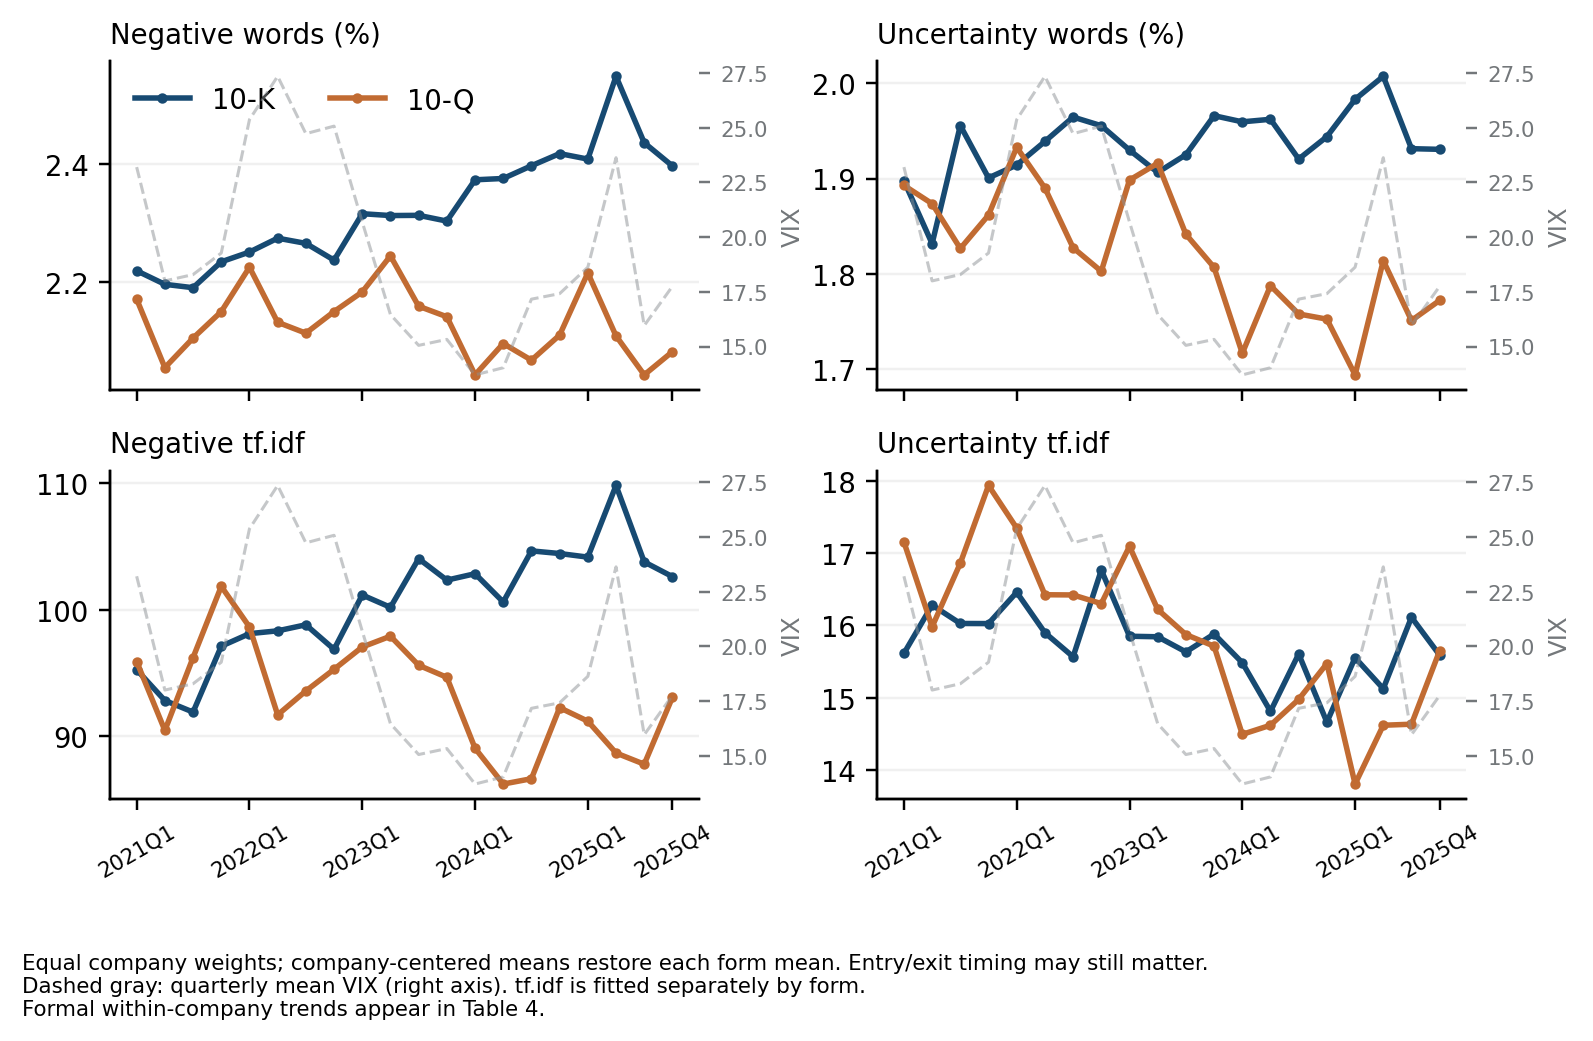

In [10]:
display(Image(filename=str(OUTPUT_DIR / 'figure1.png')))

## Outcome specifications

For uncertainty $U$, the volatility model is

$$\sigma^{post}_{iq}=\alpha_i+\lambda_q+\beta U_{iq}
+\gamma_1\ln(Size_{iq})+\gamma_2\ln(DollarVolume_{iq})
+\gamma_3R^{pre,excess}_{iq}+\theta K_{iq}
+[\rho\sigma^{pre}_{iq}]+\varepsilon_{iq}.$$

Both proportional and weighted uncertainty are estimated with and without
the bracketed pre-filing volatility control, using exactly the same complete
observations within each comparison. $\lambda_q$ is a calendar-quarter effect.
Dollar volume and prior excess return use [−60,−6]; size uses the day −1 price
and shares printed on the scored filing.

For negative sentiment $N$, the filing-return model is

$$R^{[0,3],excess}_{iq}=\alpha_i+\lambda_q+\beta N_{iq}
+\gamma_1\ln(Size_{iq})+\gamma_2\ln(DollarVolume_{iq})
+\gamma_3R^{pre,excess}_{iq}+\rho\sigma^{pre}_{iq}
+\theta K_{iq}+\varepsilon_{iq}.$$

Both tone versions use firm and quarter effects, all listed controls, and the
same two clustering alternatives. No winsorisation is applied. Coefficients
are per one unit of the original score. One-standard-deviation effects aid
comparison. The approximate two-sided 5% test's 80% minimum detectable effect
is $(t_{.975,df}+\Phi^{-1}(.8))SE$; its standardised-tone counterpart multiplies
by the score's standard deviation. Statistical insignificance does not establish
that the association is zero, and these associations are not causal effects.


## Table 5. Uncertainty and post-filing volatility

In [11]:
table5 = show_table(5)

,model,outcome,term,inference,n,firm_clusters,quarter_clusters,coef,se,t,p,ci_low,ci_high,mde80,df_inference,r_squared,controls,fixed_effects,form_control,dropped_nuisance,design_rank,status,measure,sample,tone_sd,effect_1sd,mde80_1sd
0,volatility_without_prevol,post_vol,Uncertainty_prop,firm_cluster,1437,84,20,-0.16876,1.62966,-0.10356,0.91777,-3.41010,3.07258,4.61290,83,0.69626,"Uncertainty_prop,log_size,log_dollar_volume,pre_excess","cik,quarter",True,—,108,ok,Uncertainty_prop,All,0.00522,-0.00088,0.02408
1,volatility_without_prevol,post_vol,Uncertainty_prop,firm_quarter_cluster,1437,84,20,-0.16876,1.43740,-0.11741,0.90777,-3.17726,2.83974,4.21825,19,0.69626,"Uncertainty_prop,log_size,log_dollar_volume,pre_excess","cik,quarter",True,—,108,ok,Uncertainty_prop,All,0.00522,-0.00088,0.02202
2,volatility_with_prevol,post_vol,Uncertainty_prop,firm_cluster,1437,84,20,-0.72056,1.43912,-0.50070,0.61791,-3.58291,2.14179,4.07354,83,0.70512,"Uncertainty_prop,log_size,log_dollar_volume,pre_excess,pre_vol","cik,quarter",True,—,109,ok,Uncertainty_prop,All,0.00522,-0.00376,0.02127
3,volatility_with_prevol,post_vol,Uncertainty_prop,firm_quarter_cluster,1437,84,20,-0.72056,1.27187,-0.56653,0.57766,-3.38262,1.94150,3.73250,19,0.70512,"Uncertainty_prop,log_size,log_dollar_volume,pre_excess,pre_vol","cik,quarter",True,—,109,ok,Uncertainty_prop,All,0.00522,-0.00376,0.01949
4,volatility_without_prevol,post_vol,Uncertainty_tfidf,firm_cluster,1437,84,20,0.00017,0.00106,0.16038,0.87297,-0.00193,0.00227,0.00299,83,0.69626,"Uncertainty_tfidf,log_size,log_dollar_volume,pre_excess","cik,quarter",True,—,108,ok,Uncertainty_tfidf,All,9.49314,0.00161,0.02836
5,volatility_without_prevol,post_vol,Uncertainty_tfidf,firm_quarter_cluster,1437,84,20,0.00017,0.00082,0.20647,0.83862,-0.00155,0.00189,0.00241,19,0.69626,"Uncertainty_tfidf,log_size,log_dollar_volume,pre_excess","cik,quarter",True,—,108,ok,Uncertainty_tfidf,All,9.49314,0.00161,0.02284
6,volatility_with_prevol,post_vol,Uncertainty_tfidf,firm_cluster,1437,84,20,-0.00015,0.00094,-0.15782,0.87498,-0.00202,0.00173,0.00267,83,0.70507,"Uncertainty_tfidf,log_size,log_dollar_volume,pre_excess,pre_vol","cik,quarter",True,—,109,ok,Uncertainty_tfidf,All,9.49314,-0.00141,0.02533
7,volatility_with_prevol,post_vol,Uncertainty_tfidf,firm_quarter_cluster,1437,84,20,-0.00015,0.00075,-0.19920,0.84422,-0.00171,0.00141,0.00219,19,0.70507,"Uncertainty_tfidf,log_size,log_dollar_volume,pre_excess,pre_vol","cik,quarter",True,—,109,ok,Uncertainty_tfidf,All,9.49314,-0.00141,0.02081
8,volatility_without_prevol,post_vol,Uncertainty_prop,firm_cluster,349,83,20,-16.26437,23.02698,-0.70632,0.48199,-62.07236,29.54363,65.18799,82,0.79261,"Uncertainty_prop,log_size,log_dollar_volume,pre_excess","cik,quarter",False,cik_0000896878,105,ok,Uncertainty_prop,10-K,0.00243,-0.03952,0.15840
9,volatility_without_prevol,post_vol,Uncertainty_prop,firm_quarter_cluster,349,83,20,-16.26437,21.43520,-0.75877,0.45730,-61.12875,28.60002,62.90471,19,0.79261,"Uncertainty_prop,log_size,log_dollar_volume,pre_excess","cik,quarter",False,cik_0000896878,105,ok,Uncertainty_prop,10-K,0.00243,-0.03952,0.15285


## Table 6. Negative sentiment and filing-period excess return

In [12]:
table6 = show_table(6)

,model,outcome,term,inference,n,firm_clusters,quarter_clusters,coef,se,t,p,ci_low,ci_high,mde80,df_inference,r_squared,controls,fixed_effects,form_control,dropped_nuisance,design_rank,status,measure,sample,tone_sd,effect_1sd,mde80_1sd
0,filing_return,event_excess,Negative_prop,firm_cluster,1437,84,20,-1.02163,0.71986,-1.41922,0.15958,-2.45340,0.41013,2.03761,83,0.09947,"Negative_prop,log_size,log_dollar_volume,pre_excess,pre_vol","cik,quarter",True,—,109,ok,Negative_prop,All,0.00848,-0.00866,0.01727
1,filing_return,event_excess,Negative_prop,firm_quarter_cluster,1437,84,20,-1.02163,0.74791,-1.36598,0.18790,-2.58703,0.54377,2.19486,19,0.09947,"Negative_prop,log_size,log_dollar_volume,pre_excess,pre_vol","cik,quarter",True,—,109,ok,Negative_prop,All,0.00848,-0.00866,0.01860
2,filing_return,event_excess,Negative_tfidf,firm_cluster,1437,84,20,-0.00015,0.00010,-1.50721,0.13555,-0.00034,0.00005,0.00027,83,0.09989,"Negative_tfidf,log_size,log_dollar_volume,pre_excess,pre_vol","cik,quarter",True,—,109,ok,Negative_tfidf,All,73.16345,-0.01070,0.02010
3,filing_return,event_excess,Negative_tfidf,firm_quarter_cluster,1437,84,20,-0.00015,0.00012,-1.26699,0.22047,-0.00039,0.00010,0.00034,19,0.09989,"Negative_tfidf,log_size,log_dollar_volume,pre_excess,pre_vol","cik,quarter",True,—,109,ok,Negative_tfidf,All,73.16345,-0.01070,0.02479
4,filing_return,event_excess,Negative_prop,firm_cluster,349,83,20,-6.78194,7.80601,-0.86881,0.38749,-22.31057,8.74669,22.09833,82,0.27512,"Negative_prop,log_size,log_dollar_volume,pre_excess,pre_vol","cik,quarter",False,cik_0000896878,106,ok,Negative_prop,10-K,0.00401,-0.02718,0.08858
5,filing_return,event_excess,Negative_prop,firm_quarter_cluster,349,83,20,-6.78194,8.48661,-0.79913,0.43409,-24.54462,10.98073,24.90518,19,0.27512,"Negative_prop,log_size,log_dollar_volume,pre_excess,pre_vol","cik,quarter",False,cik_0000896878,106,ok,Negative_prop,10-K,0.00401,-0.02718,0.09983
6,filing_return,event_excess,Negative_tfidf,firm_cluster,349,83,20,-0.00079,0.00107,-0.74125,0.46066,-0.00291,0.00133,0.00302,82,0.27439,"Negative_tfidf,log_size,log_dollar_volume,pre_excess,pre_vol","cik,quarter",False,cik_0000896878,106,ok,Negative_tfidf,10-K,38.30635,-0.03025,0.11553
7,filing_return,event_excess,Negative_tfidf,firm_quarter_cluster,349,83,20,-0.00079,0.00076,-1.04501,0.30913,-0.00237,0.00079,0.00222,19,0.27439,"Negative_tfidf,log_size,log_dollar_volume,pre_excess,pre_vol","cik,quarter",False,cik_0000896878,106,ok,Negative_tfidf,10-K,38.30635,-0.03025,0.08495
8,filing_return,event_excess,Negative_prop,firm_cluster,1088,83,20,-2.91987,1.02846,-2.83907,0.00570,-4.96580,-0.87393,2.91151,82,0.13295,"Negative_prop,log_size,log_dollar_volume,pre_excess,pre_vol","cik,quarter",False,—,107,ok,Negative_prop,10-Q,0.00942,-0.02751,0.02743
9,filing_return,event_excess,Negative_prop,firm_quarter_cluster,1088,83,20,-2.91987,1.27031,-2.29855,0.03305,-5.57865,-0.26108,3.72791,19,0.13295,"Negative_prop,log_size,log_dollar_volume,pre_excess,pre_vol","cik,quarter",False,—,107,ok,Negative_prop,10-Q,0.00942,-0.02751,0.03512


## AI assistance

OpenAI Codex generated analysis code, tests and notebook text and assisted with
data acquisition and execution. Numerical outputs are produced by running the
analysis on the acquired corpus; they are not supplied as invented examples.
This statement does not imply that the student independently wrote or reviewed
the generated code. The accompanying AI-use disclosure records the assistance.
